# Implementation of MultiFoundationCore (MFC)

=================================================

This script cleans and organizes the original notebook into a reproducible pipeline:

1. Load and merge expert prediction files.
2. Build supervised MFC windows for multi-horizon forecasting.
3. Define the MultiFoundationCore cross-attention model.
4. Train, evaluate, and optionally compare against individual expert models.

Core design:
- Expert prediction streams are treated as independent tokens.
- The observed target/history stream is encoded separately.
- Cross-attention uses the target/history embedding as the query and expert embeddings
  as keys/values.
- The target-history stream repeats the last observed value at the first forecasted row
  so that the model never receives the true y_{t+1} as input.

Assumption about expert columns:
- A feature row for t+1 may contain expert predictions for t+1 only if those predictions
  were generated using information available up to time t.
"""

# Results Across 5 Runs

This section reports the updated performance of **MultiFoundationCore** across five independent runs.  
Lower values are better for **MSE**, **MAE**, and **SMAPE**. Higher values are better for **NNSE** and **R²**.

---

## Overall Mean Performance Across 5 Runs

| Metric | Mean | Std. Dev. |
|---|---:|---:|
| **MSE ↓** | **0.381649** | 0.007732 |
| **MAE ↓** | **0.375617** | 0.002729 |
| **SMAPE ↓** | **15.578367** | 0.157813 |
| **NNSE ↑** | **0.863655** | 0.002365 |
| **R² ↑** | **0.836832** | 0.003317 |

---


## Cross-Run Average by Forecast Horizon

| Horizon | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|
| 1 | 0.118002 | 0.208565 | 8.652771 | 0.949049 | 0.946309 |
| 2 | 0.306495 | 0.336833 | 13.757757 | 0.881752 | 0.865886 |
| 3 | 0.474855 | 0.439076 | 18.179022 | 0.832005 | 0.798074 |
| 4 | 0.627242 | 0.517994 | 21.723917 | 0.791815 | 0.737060 |

---

# Detailed Results

## Run 1

| Horizon | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|
| 1 | 0.117786 | 0.210802 | 8.906023 | 0.949133 | 0.946407 |
| 2 | 0.297478 | 0.335338 | 13.738601 | 0.884824 | 0.869832 |
| 3 | 0.469388 | 0.448917 | 18.582777 | 0.833611 | 0.800399 |
| 4 | 0.610762 | 0.525877 | 21.988354 | 0.796158 | 0.743968 |
| **Mean** | **0.373853** | **0.380234** | **15.803939** | **0.865932** | **0.840152** |

---

## Run 2

| Horizon | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|
| 1 | 0.111502 | 0.202214 | 8.362251 | 0.951716 | 0.949266 |
| 2 | 0.299700 | 0.336961 | 13.909732 | 0.884064 | 0.868860 |
| 3 | 0.462902 | 0.436105 | 18.389473 | 0.835531 | 0.803157 |
| 4 | 0.616218 | 0.516533 | 21.971031 | 0.794711 | 0.741681 |
| **Mean** | **0.372580** | **0.372953** | **15.658122** | **0.866506** | **0.840741** |

---

## Run 3

| Horizon | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|
| 1 | 0.116177 | 0.204481 | 8.360088 | 0.949793 | 0.947139 |
| 2 | 0.312572 | 0.335399 | 13.577626 | 0.879683 | 0.863227 |
| 3 | 0.487334 | 0.440740 | 18.081280 | 0.828341 | 0.792768 |
| 4 | 0.634217 | 0.518200 | 21.540560 | 0.789974 | 0.734136 |
| **Mean** | **0.387575** | **0.374705** | **15.389889** | **0.861948** | **0.834317** |

---

## Run 4

| Horizon | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|
| 1 | 0.126440 | 0.214902 | 8.823193 | 0.945599 | 0.942470 |
| 2 | 0.313600 | 0.337840 | 13.788385 | 0.879335 | 0.862777 |
| 3 | 0.476046 | 0.432677 | 17.929913 | 0.831648 | 0.797568 |
| 4 | 0.635447 | 0.514802 | 21.523991 | 0.789653 | 0.733621 |
| **Mean** | **0.387883** | **0.375055** | **15.516370** | **0.861559** | **0.834109** |

---

## Run 5

| Horizon | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|
| 1 | 0.118107 | 0.210426 | 8.812298 | 0.949002 | 0.946261 |
| 2 | 0.309126 | 0.338628 | 13.774443 | 0.880852 | 0.864735 |
| 3 | 0.478607 | 0.436940 | 17.911669 | 0.830895 | 0.796479 |
| 4 | 0.639567 | 0.514556 | 21.595648 | 0.788577 | 0.731893 |
| **Mean** | **0.386352** | **0.375137** | **15.523514** | **0.862331** | **0.834842** |

In [ ]:
"""
Clean implementation of MultiFoundationCore (MFC)
=================================================
"""

from __future__ import annotations

import os
import random
from dataclasses import dataclass, field
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Add,
    Dense,
    Dropout,
    Input,
    Lambda,
    LayerNormalization,
    LSTM,
    MultiHeadAttention,
)
from tensorflow.keras.models import Model


# =============================================================================
# Configuration
# =============================================================================


@dataclass(frozen=True)
class MFCConfig:
    """Configuration for data construction, model training, and evaluation."""

    # Paths
    prediction_dir: str = "./Predictoins"

    # Data construction
    test_length: int = 200
    look_back_size: int = 10
    output_horizon: int = 4
    group_col: str = "unique_id"
    time_col: str = "ds"
    target_col: str = "y"

    # Expert/model names. These names should match the prefixes used in the
    # prediction files after `filename.split('_')[0]`.
    expert_model_names: tuple[str, ...] = (
        # These names reproduce the feature list in the original notebook.
        # The loaded folder may also contain TFT or TiDE; include them here manually
        # or set use_all_available_experts=True if you want MFC to use every loaded expert.
        "PatchTST",
        "PatchTSTm",
        "PatchTSTt",
        "PatchTSTc",
        "VanillaTransformer",
        "iTransformer",
        "iTransformerh",
        "PatchTSTh",
        "TFT",
        "TiDE",
    )

    # If True, ignore expert_model_names and use every model loaded from prediction_dir.
    # This changes the experiment relative to the original notebook.
    use_all_available_experts: bool = False

    # The notebook used os.listdir('./Predictoins/') order. Keep False to reproduce that
    # behavior. Set True only if all files have identical actual columns and you
    # want deterministic file loading independent of filesystem order.
    sort_prediction_files: bool = False

    # Validate that ds/unique_id/y_actual_* are identical across all .pkl files
    # before dropping them from later files. This prevents silent misalignment.
    validate_actual_columns: bool = True

    # If True, run plots at the end of run_pipeline. Disable on HPC/headless runs.
    make_plots: bool = True

    # If True, missing expert names are dropped with a warning instead of crashing.
    # This is useful when you run the same script with different folders of expert files.
    drop_missing_experts: bool = True

    # Architecture
    expert_lstm_units: int = 8
    history_lstm_units: int = 8
    num_heads: int = 4
    key_dim: int = 16
    value_dim: int = 16
    ff_units: int = 16
    decoder_units: int = 16
    dropout_rate: float = 0.10

    # Optimization
    learning_rate: float = 1e-4
    batch_size: int = 32
    epochs: int = 450
    seed: int = 100

    # Training callbacks
    use_early_stopping: bool = False
    early_stopping_patience: int = 25
    use_reduce_lr: bool = False
    reduce_lr_patience: int = 8
    reduce_lr_factor: float = 0.5
    min_lr: float = 1e-6


# =============================================================================
# Reproducibility utilities
# =============================================================================


def set_global_seed(seed: int) -> None:
    """Set random seeds for reproducibility."""

    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


# =============================================================================
# Loading and merging expert predictions
# =============================================================================


def expected_prediction_columns(model_name: str, output_horizon: int) -> list[str]:
    """Return expected prediction column names for one expert model."""

    return [f"{h}_{model_name}" for h in range(1, output_horizon + 1)]


def expected_actual_columns(output_horizon: int) -> list[str]:
    """Return expected ground-truth horizon column names."""

    return [f"y_actual_{h}" for h in range(1, output_horizon + 1)]


def make_feature_columns(model_names: Sequence[str], output_horizon: int) -> list[str]:
    """Return ordered model-horizon prediction feature columns.

    The order is horizon-major, matching the original notebook:
        1_PatchTST, 1_PatchTSTm, ..., 2_PatchTST, 2_PatchTSTm, ...

    Each column is treated as one expert token by MFC. Therefore the current
    implementation uses one token per (model, horizon) prediction stream.
    """

    return [
        f"{h}_{model_name}"
        for h in range(1, output_horizon + 1)
        for model_name in model_names
    ]


def feature_columns(config: MFCConfig) -> list[str]:
    """Build the ordered feature list from the configured expert model names."""

    return make_feature_columns(config.expert_model_names, config.output_horizon)


def load_single_prediction_file(
    file_path: Path,
    output_horizon: int,
) -> tuple[str, pd.DataFrame]:
    """
    Load one .pkl file containing expert predictions.

    Expected raw column order:
        ds, unique_id,
        horizon-1 prediction, ..., horizon-H prediction,
        y_actual_1, ..., y_actual_H

    The model name is inferred from the filename prefix before the first underscore,
    which matches the behavior of the original notebook.
    """

    model_name = file_path.stem.split("_")[0]
    pred_cols = expected_prediction_columns(model_name, output_horizon)
    actual_cols = expected_actual_columns(output_horizon)

    df_model = pd.read_pickle(file_path).copy()
    expected_n_cols = 2 + output_horizon + output_horizon

    if df_model.shape[1] != expected_n_cols:
        raise ValueError(
            f"File {file_path.name} has {df_model.shape[1]} columns, but expected "
            f"{expected_n_cols}: ds, unique_id, {output_horizon} predictions, "
            f"and {output_horizon} actual columns."
        )

    df_model.columns = ["ds", "unique_id", *pred_cols, *actual_cols]
    return model_name, df_model


def split_last_n_by_group(
    data: pd.DataFrame,
    group_col: str,
    n_last: int,
    group_order: Sequence[object] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split each time series into:
        train_part = all rows except the last n_last rows
        test_part  = the last n_last rows

    This reproduces the notebook's `splitter(...)` behavior used in expert
    baseline cells. It preserves within-group row order. When group_order is
    supplied, groups are concatenated in that explicit order so y_df and df are
    reshaped consistently.
    """

    if n_last < 0:
        raise ValueError(f"n_last must be non-negative, got {n_last}.")

    train_parts: list[pd.DataFrame] = []
    test_parts: list[pd.DataFrame] = []

    if group_order is None:
        group_order = list(data[group_col].drop_duplicates())

    for grp_value in group_order:
        group = data[data[group_col] == grp_value]
        if group.empty:
            raise ValueError(f"Group {grp_value!r} is missing from dataframe.")

        if n_last == 0:
            train_parts.append(group.copy())
            test_parts.append(group.iloc[0:0].copy())
        else:
            train_parts.append(group.iloc[:-n_last].copy())
            test_parts.append(group.iloc[-n_last:].copy())

    train = pd.concat(train_parts, axis=0) if train_parts else data.iloc[0:0].copy()
    test = pd.concat(test_parts, axis=0) if test_parts else data.iloc[0:0].copy()
    return train, test


def load_and_merge_predictions(config: MFCConfig) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    """
    Load prediction files using notebook-compatible horizontal concatenation.

    The original notebook horizontally concatenated expert prediction files. The
    first file supplied the shared columns:
        ds, unique_id, y_actual_1, ..., y_actual_H
    and later files contributed only their prediction columns.

    This function preserves that behavior while making the safety checks clearer:

    1. Hard check:
       ds and unique_id must match row-by-row across all expert files.
       If these keys differ, the expert files are not aligned and the function
       raises an error.

    2. Soft check:
       y_actual_* columns may differ slightly across files, especially when some
       experts were generated with target-date-aligned rows and trailing NaNs.
       In that case, we warn but continue, because MFC uses y_actual_* only from
       the first loaded file. Later actual columns are dropped exactly like the
       original notebook.

    Returns
    -------
    df:
        Main modeling dataframe with ds, unique_id, expert prediction columns,
        and y = y_actual_1. Rows with missing expert values are dropped.

    y_df:
        Ground-truth dataframe with ds, unique_id, y_actual_1,...,y_actual_H,
        copied before actual columns are dropped.

    used_features:
        Expert prediction columns used by MFC.
    """

    prediction_dir = Path(config.prediction_dir)

    # Match notebook behavior by default: os.listdir order.
    pkl_files = [prediction_dir / name for name in os.listdir(prediction_dir) if name.endswith(".pkl")]
    if config.sort_prediction_files:
        pkl_files = sorted(pkl_files)

    if not pkl_files:
        raise FileNotFoundError(f"No .pkl prediction files found in {prediction_dir.resolve()}.")

    actual_cols = expected_actual_columns(config.output_horizon)
    key_cols = [config.time_col, config.group_col]
    shared_cols = key_cols + actual_cols

    data_frames: list[pd.DataFrame] = []
    loaded_models: list[str] = []
    reference_shared: pd.DataFrame | None = None

    for file_idx, file_path in enumerate(pkl_files):
        model_name, df_model = load_single_prediction_file(file_path, config.output_horizon)

        if model_name in loaded_models:
            raise ValueError(
                f"Duplicate inferred expert name '{model_name}'. This happens when multiple files "
                f"share the same prefix before the first underscore. Rename files or change "
                f"load_single_prediction_file() so each expert has a unique name."
            )

        loaded_models.append(model_name)
        print(f"Loaded {file_path.name} as expert '{model_name}'.")

        current_shared = df_model[shared_cols].reset_index(drop=True)

        if file_idx == 0:
            # The first file defines the official ds/unique_id/y_actual_* table.
            reference_shared = current_shared.copy()
        elif config.validate_actual_columns:
            assert reference_shared is not None

            # ------------------------------------------------------------
            # 1. HARD CHECK: ds and unique_id must be aligned row-by-row.
            # ------------------------------------------------------------
            ref_keys = reference_shared[key_cols].reset_index(drop=True)
            cur_keys = current_shared[key_cols].reset_index(drop=True)

            key_mismatch = (ref_keys != cur_keys).any(axis=1)
            if key_mismatch.any():
                bad = pd.concat(
                    [
                        ref_keys.loc[key_mismatch].reset_index(drop=True).add_prefix("reference_"),
                        cur_keys.loc[key_mismatch].reset_index(drop=True).add_prefix("current_"),
                    ],
                    axis=1,
                ).head(10)

                raise ValueError(
                    f"The key columns in {file_path.name} do not match the first loaded file. "
                    "Rows are not aligned by ds and unique_id. First mismatched rows:\n"
                    f"{bad}"
                )

            # ------------------------------------------------------------
            # 2. SOFT CHECK: y_actual_* can differ; warn, do not crash.
            #    Later y_actual_* columns are dropped, so the first file is
            #    the single source of ground truth for y_df.
            # ------------------------------------------------------------
            mismatch_summaries: list[str] = []

            for col in actual_cols:
                ref_vals = pd.to_numeric(reference_shared[col], errors="coerce").to_numpy(dtype=float)
                cur_vals = pd.to_numeric(current_shared[col], errors="coerce").to_numpy(dtype=float)

                same = np.isclose(ref_vals, cur_vals, rtol=1e-6, atol=1e-8, equal_nan=True)
                n_bad = int((~same).sum())

                if n_bad > 0:
                    diff = np.abs(ref_vals[~same] - cur_vals[~same])
                    max_abs_diff = float(np.nanmax(diff)) if np.isfinite(diff).any() else np.nan
                    mismatch_summaries.append(
                        f"{col}: {n_bad} mismatched rows, max_abs_diff={max_abs_diff}"
                    )

            if mismatch_summaries:
                print(
                    f"\nWarning: y_actual_* columns in {file_path.name} differ from the first loaded file."
                )
                print(
                    "This is allowed because only the first file supplies y_df; "
                    "later y_actual_* columns are dropped."
                )
                for line in mismatch_summaries:
                    print(f"  - {line}")

        if file_idx > 0:
            # Exactly like the notebook: keep only prediction columns from later files.
            df_model = df_model.drop(shared_cols, axis=1)

        data_frames.append(df_model)

    results_df = pd.concat(data_frames, axis=1)

    # Ground truth is copied from the first loaded file before actual columns are
    # dropped from the modeling dataframe.
    y_df = results_df[[config.time_col, config.group_col, *actual_cols]].copy()

    # Modeling target used by the MFC windows.
    results_df[config.target_col] = results_df["y_actual_1"]
    df = results_df.drop(actual_cols, axis=1).dropna().copy()

    # Resolve experts to use.
    if config.use_all_available_experts:
        configured_models = list(loaded_models)
        available_models = list(loaded_models)
        missing_models: list[str] = []
    else:
        configured_models = list(config.expert_model_names)
        available_models = [model for model in configured_models if model in loaded_models]
        missing_models = [model for model in configured_models if model not in loaded_models]

    if missing_models:
        message = (
            "The following configured expert names were not found in the loaded files: "
            f"{missing_models}. Loaded model names are: {loaded_models}."
        )
        if config.drop_missing_experts:
            print("\nWarning:", message)
            print("Dropping missing experts and continuing with available experts only.")
        else:
            raise ValueError(message)

    if not available_models:
        raise ValueError(
            "No configured expert models were found in the loaded files. "
            f"Configured: {configured_models}. Loaded: {loaded_models}."
        )

    used_features = make_feature_columns(available_models, config.output_horizon)
    missing_features = [col for col in used_features if col not in df.columns]
    if missing_features:
        raise ValueError(
            "Some expected expert feature columns are missing.\n"
            f"Missing: {missing_features}\n"
            f"Available model names used: {available_models}\n"
            f"Loaded model names: {loaded_models}"
        )

    # Notebook-compatible asymmetry: df is sorted for MFC windows; y_df is kept
    # in positional order for baseline reproduction.
    df = df.sort_values([config.group_col, config.time_col]).reset_index(drop=True)
    y_df = y_df.reset_index(drop=True)

    print("\nLoaded prediction dataframe using notebook-compatible concatenation.")
    print(f"Loaded expert models: {loaded_models}")
    print(f"Expert models used by MFC: {available_models}")
    print(f"Number of expert prediction features: {len(used_features)}")
    print(f"Number of rows in df after dropna: {len(df)}")
    print(f"Number of rows in y_df: {len(y_df)}")

    return df, y_df, used_features



# =============================================================================
# Supervised window construction
# =============================================================================


def build_mfc_supervised_arrays(
    df: pd.DataFrame,
    features: Sequence[str],
    config: MFCConfig,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Convert merged prediction dataframe into MFC input/output arrays.

    For each sample index i, the notebook constructs:

        expert window  = feature_data[i - L : i]
        history window = y[i - L : i], but with the last value replaced
                         by the previous value.
        target         = y[i - 1 : i - 1 + H]

    With H=4, the target is:
        [y_{t+1}, y_{t+2}, y_{t+3}, y_{t+4}]

    The history replacement is important. It avoids giving the model y_{t+1};
    instead the first unknown target-history value is replaced by y_t.

    Notes
    -----
    This function preserves your original indexing because your expert rows are
    target-date aligned: the row corresponding to t+1 contains forecasts for t+1
    produced using information only up to t.
    """

    look_back_size = config.look_back_size
    output_horizon = config.output_horizon
    test_length = config.test_length

    train_x: list[np.ndarray] = []
    train_y: list[np.ndarray] = []
    test_x: list[np.ndarray] = []
    test_y: list[np.ndarray] = []

    required_cols = [config.group_col, config.time_col, *features, config.target_col]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in dataframe: {missing}")

    df = df.sort_values([config.group_col, config.time_col]).reset_index(drop=True)

    for unique_id, ts_data in df.groupby(config.group_col, sort=False):
        ts_data = ts_data.reset_index(drop=True)
        ts_length = len(ts_data)
        split_point = ts_length - test_length

        if split_point <= look_back_size + 1:
            raise ValueError(
                f"Time series {unique_id!r} is too short for look_back_size={look_back_size} "
                f"and test_length={test_length}. Length={ts_length}."
            )

        feature_data = ts_data[list(features)].to_numpy(dtype=np.float32)
        target_data = ts_data[config.target_col].to_numpy(dtype=np.float32)

        def add_samples(start: int, end: int, x_store: list[np.ndarray], y_store: list[np.ndarray]) -> None:
            """Append samples for i in [start, end)."""

            for i in range(start, end):
                # Expert prediction streams, shape: (look_back_size, num_expert_features)
                expert_window = feature_data[i - look_back_size : i]

                # Target/history stream, shape: (look_back_size, 1)
                history_window = target_data[i - look_back_size : i].reshape(look_back_size, 1).copy()

                # Prevent true y_{t+1} from entering the input. The last row is aligned with
                # the first predicted target date, so replace it with the last observed value.
                history_window[-1, 0] = history_window[-2, 0]

                # Final input shape: (look_back_size, num_expert_features + 1)
                x_sample = np.hstack([expert_window, history_window]).astype(np.float32)

                # Multi-horizon target, shape: (output_horizon,)
                y_sample = target_data[i - 1 : i - 1 + output_horizon].astype(np.float32)

                if y_sample.shape[0] != output_horizon:
                    raise RuntimeError(
                        f"Invalid target length for group={unique_id}, i={i}: "
                        f"got {y_sample.shape[0]}, expected {output_horizon}."
                    )

                x_store.append(x_sample)
                y_store.append(y_sample)

        # Training targets must end before the test region starts.
        train_start = look_back_size + 1
        train_end = split_point - output_horizon + 2

        # Test targets start at the first test row and must have all H horizons available.
        test_start = split_point + 1
        test_end = ts_length - output_horizon + 2

        add_samples(train_start, train_end, train_x, train_y)
        add_samples(test_start, test_end, test_x, test_y)

    x_train = np.asarray(train_x, dtype=np.float32)
    y_train = np.asarray(train_y, dtype=np.float32)
    x_test = np.asarray(test_x, dtype=np.float32)
    y_test = np.asarray(test_y, dtype=np.float32)

    print("\nConstructed supervised arrays:")
    print(f"X_train: {x_train.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"X_test:  {x_test.shape}")
    print(f"y_test:  {y_test.shape}")

    return x_train, y_train, x_test, y_test


# =============================================================================
# MultiFoundationCore model
# =============================================================================


def build_multifoundation_core_model(
    time_steps: int,
    num_features: int,
    output_horizon: int,
    config: MFCConfig,
) -> Model:
    """
    Build the MultiFoundationCore cross-attention model.

    Input shape
    -----------
    (batch, time_steps, num_features)

    Feature convention
    ------------------
    - Columns 0 ... num_features-2 are expert/model-horizon prediction streams.
    - The last column is the observed target/history stream.

    Architecture
    ------------
    1. Encode each expert stream with an independent LSTM.
    2. Encode the target/history stream with a separate LSTM.
    3. Use target/history embedding as query; expert embeddings as keys/values.
    4. Fuse with residual connection
    5. Decode to H forecast horizons.
    """

    if num_features < 2:
        raise ValueError(
            f"MFC expects at least one expert feature plus one history feature; got num_features={num_features}."
        )

    inputs = Input(shape=(time_steps, num_features), name="mfc_input")

    # -------------------------------------------------------------------------
    # 1) Independent LSTM encoders for expert prediction streams
    # -------------------------------------------------------------------------
    expert_embeddings = []
    num_expert_streams = num_features - 1

    for idx in range(num_expert_streams):
        # Important: idx=idx freezes the current loop value.
        # Without this, every Lambda can accidentally point to the final idx.
        expert_stream = Lambda(
            lambda x, feature_idx=idx: x[:, :, feature_idx : feature_idx + 1],
            name=f"expert_{idx:02d}_slice",
        )(inputs)

        expert_embedding = LSTM(
            config.expert_lstm_units,
            return_sequences=False,
            name=f"expert_{idx:02d}_lstm",
        )(expert_stream)

        expert_embeddings.append(expert_embedding)

    # Shape: (batch, num_expert_streams, expert_lstm_units)
    expert_stack = Lambda(
        lambda tensors: tf.stack(tensors, axis=1),
        name="stack_expert_embeddings",
    )(expert_embeddings)

    # -------------------------------------------------------------------------
    # 2) LSTM encoder for observed target/history stream
    # -------------------------------------------------------------------------
    history_stream = Lambda(
        lambda x: x[:, :, -1:],
        name="history_slice",
    )(inputs)

    history_embedding = LSTM(
        config.history_lstm_units,
        return_sequences=False,
        name="history_lstm",
    )(history_stream)

    # Shape: (batch, 1, history_lstm_units), required by MultiHeadAttention.
    history_query = Lambda(
        lambda x: tf.expand_dims(x, axis=1),
        name="expand_history_query",
    )(history_embedding)

    # -------------------------------------------------------------------------
    # 3) Cross-attention: history attends to expert prediction tokens
    # -------------------------------------------------------------------------
    attention_output = MultiHeadAttention(
        num_heads=config.num_heads,
        key_dim=config.key_dim,
        value_dim=config.value_dim,
        dropout=config.dropout_rate,
        name="cross_attention",
    )(
        query=history_query,
        key=expert_stack,
        value=expert_stack,
    )

    # Keras MultiHeadAttention projects back to the query dimension by default,
    # so this residual connection is shape-compatible with history_query.
    fused = Add(name="residual_history_attention")([history_query, attention_output])

    # -------------------------------------------------------------------------
    # 4) Position-wise feed-forward block
    # -------------------------------------------------------------------------
    ff = Dense(config.ff_units, activation="relu", name="ffn_dense_1")(fused)
    ff = Dense(config.history_lstm_units, activation="linear", name="ffn_dense_2")(ff)

    fused = Add(name="residual_ffn")([fused, ff])

    # -------------------------------------------------------------------------
    # 5) Decoder and multi-horizon output
    # -------------------------------------------------------------------------
    representation = Lambda(
        lambda x: tf.squeeze(x, axis=1),
        name="remove_token_dimension",
    )(fused)

    representation = Dense(
        config.decoder_units,
        activation="relu",
        name="decoder_dense",
    )(representation)

    outputs = Dense(
        output_horizon,
        activation="linear",
        name="forecast_output",
    )(representation)

    model = Model(inputs=inputs, outputs=outputs, name="MultiFoundationCore")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config.learning_rate),
        loss="mse",
    )

    return model


# =============================================================================
# Training utilities
# =============================================================================


class PrintLossCallback(Callback):
    """Print compact train/validation losses after each epoch."""

    def on_epoch_end(self, epoch: int, logs: dict | None = None) -> None:
        logs = logs or {}
        train_loss = logs.get("loss")
        val_loss = logs.get("val_loss")

        if train_loss is None or val_loss is None:
            return

        print(
            f"Epoch {epoch + 1:03d} | "
            f"train MSE: {train_loss:.6f} | "
            f"val MSE: {val_loss:.6f}"
        )


def build_callbacks(config: MFCConfig) -> list[Callback]:
    """Create training callbacks from the configuration."""

    callbacks: list[Callback] = [PrintLossCallback()]

    if config.use_early_stopping:
        callbacks.append(
            EarlyStopping(
                monitor="val_loss",
                patience=config.early_stopping_patience,
                restore_best_weights=True,
            )
        )

    if config.use_reduce_lr:
        callbacks.append(
            ReduceLROnPlateau(
                monitor="val_loss",
                factor=config.reduce_lr_factor,
                patience=config.reduce_lr_patience,
                min_lr=config.min_lr,
            )
        )

    return callbacks


def train_model(
    model: Model,
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    config: MFCConfig,
) -> tf.keras.callbacks.History:
    """Train MFC using the same test split as validation, matching the notebook."""

    history = model.fit(
        x_train,
        y_train,
        epochs=config.epochs,
        batch_size=config.batch_size,
        validation_data=(x_test, y_test),
        callbacks=build_callbacks(config),
        verbose=1,
    )

    test_loss = model.evaluate(x_test, y_test, batch_size=config.batch_size, verbose=1)
    print(f"\nFinal test MSE loss: {test_loss:.6f}")

    return history


# =============================================================================
# Metrics and evaluation
# =============================================================================


def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.square(y_true - y_pred)))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def smape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)))


def r2_score_np(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12) -> float:
    numerator = np.sum(np.square(y_true - y_pred))
    denominator = np.sum(np.square(y_true - np.mean(y_true)))
    return float(1.0 - numerator / (denominator + eps))


def nnse(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12) -> float:
    """
    Normalized Nash-Sutcliffe Efficiency.

    NSE  = 1 - SSE / SST
    NNSE = 1 / (2 - NSE)
    """

    nse = r2_score_np(y_true, y_pred, eps=eps)
    return float(1.0 / (2.0 - nse))


def evaluate_multihorizon_predictions(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    output_horizon: int,
) -> pd.DataFrame:
    """Evaluate one direct multi-horizon model output."""

    rows = []

    for h_idx in range(output_horizon):
        yt = y_true[:, h_idx].reshape(-1)
        yp = y_pred[:, h_idx].reshape(-1)

        rows.append(
            {
                "horizon": h_idx + 1,
                "MSE": mse(yt, yp),
                "MAE": mae(yt, yp),
                "SMAPE": smape(yt, yp),
                "NNSE": nnse(yt, yp),
                "R2": r2_score_np(yt, yp),
            }
        )

    metrics = pd.DataFrame(rows)

    mean_row = {"horizon": "mean"}
    for col in ["MSE", "MAE", "SMAPE", "NNSE", "R2"]:
        mean_row[col] = metrics[col].mean()
    metrics = pd.concat([metrics, pd.DataFrame([mean_row])], ignore_index=True)

    return metrics


def print_metrics_table(metrics: pd.DataFrame, title: str) -> None:
    """Pretty-print a metrics dataframe."""

    print(f"\n{title}")
    print("=" * len(title))
    print(metrics.to_string(index=False, float_format=lambda x: f"{x:.6f}"))


def predict_and_evaluate(
    model: Model,
    x_test: np.ndarray,
    y_test: np.ndarray,
    config: MFCConfig,
) -> tuple[np.ndarray, pd.DataFrame]:
    """Run prediction and evaluate all forecast horizons."""

    y_pred = model.predict(x_test, batch_size=config.batch_size)
    metrics = evaluate_multihorizon_predictions(y_test, y_pred, config.output_horizon)
    print_metrics_table(metrics, "MultiFoundationCore test metrics")
    return y_pred, metrics


def get_available_expert_names(df: pd.DataFrame, output_horizon: int) -> list[str]:
    """Return expert names that have complete 1..H prediction columns."""

    experts: list[str] = []
    for col in df.columns:
        if not col.startswith("1_"):
            continue
        model_name = col.split("_", 1)[1]
        if all(f"{h}_{model_name}" in df.columns for h in range(1, output_horizon + 1)):
            experts.append(model_name)
    return sorted(set(experts))


def evaluate_all_expert_baselines(
    df: pd.DataFrame,
    y_df: pd.DataFrame,
    config: MFCConfig,
    expert_names: Sequence[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Evaluate every available expert and return full and mean-summary tables."""

    if expert_names is None:
        expert_names = get_available_expert_names(df, config.output_horizon)

    full_parts: list[pd.DataFrame] = []
    summary_rows: list[pd.Series] = []

    for expert in expert_names:
        metrics = evaluate_expert_baseline_aligned(
            df=df,
            y_df=y_df,
            model_name=expert,
            config=config,
            check_date_alignment=False,
        )
        metrics = metrics.copy()
        metrics.insert(0, "model", expert)
        full_parts.append(metrics)

        mean_row = metrics[metrics["horizon"].astype(str) == "mean"].iloc[0].copy()
        summary_rows.append(mean_row)

    full_metrics = pd.concat(full_parts, ignore_index=True) if full_parts else pd.DataFrame()
    summary = pd.DataFrame(summary_rows) if summary_rows else pd.DataFrame()
    if not summary.empty:
        summary = summary[["model", "MSE", "MAE", "SMAPE", "NNSE", "R2"]].sort_values("MSE")

    return full_metrics, summary


# =============================================================================
# Optional baseline evaluation for one expert model
# =============================================================================


def evaluate_expert_baseline_aligned(
    df: pd.DataFrame,
    y_df: pd.DataFrame,
    model_name: str,
    config: MFCConfig,
    check_date_alignment: bool = False,
) -> pd.DataFrame:
    """
    Evaluate an individual expert model exactly like the original notebook cell.

    Original notebook logic:

        train_a, test_a = splitter(y_df, 'unique_id', n_test)
        train_b, test_b = splitter(df,   'unique_id', n_test)

        if horizon > 1:
            test_a, _ = splitter(test_a, 'unique_id', horizon - 1)
            test_b, _ = splitter(test_b, 'unique_id', horizon - 1)

        Y_ACTUAL = test_a[f'y_actual_{horizon}'].values.reshape(10, n_test-horizon+1)
        Y_HAT    = test_b[f'{horizon}_{model}'].values.reshape(10, n_test-horizon+1)

    Therefore, the valid length is horizon-specific:
        h=1 -> 200, h=2 -> 199, h=3 -> 198, h=4 -> 197

    Important: this intentionally does NOT require the selected actual rows
    and prediction rows to have identical ds values. The original notebook
    evaluates y_df and df after df = results_df.dropna(), so their tail blocks
    can be shifted by a few rows. This function preserves that behavior.
    """

    rows: list[dict[str, float | int | str]] = []
    n_test = config.test_length
    group_order = list(df[config.group_col].drop_duplicates())
    n_series = len(group_order)

    missing_groups_in_y = set(group_order) - set(y_df[config.group_col].drop_duplicates())
    if missing_groups_in_y:
        raise ValueError(f"These groups are in df but missing from y_df: {sorted(missing_groups_in_y)}")

    required_actual = expected_actual_columns(config.output_horizon)
    required_pred = expected_prediction_columns(model_name, config.output_horizon)
    missing_actual = [col for col in required_actual if col not in y_df.columns]
    missing_pred = [col for col in required_pred if col not in df.columns]

    if missing_actual:
        raise ValueError(f"Missing actual columns in y_df: {missing_actual}")
    if missing_pred:
        raise ValueError(f"Missing prediction columns in df: {missing_pred}")

    # Match the notebook order: groups are already sorted by load_and_merge_predictions,
    # and split_last_n_by_group preserves within-group order.
    for horizon in range(1, config.output_horizon + 1):
        _, test_actual = split_last_n_by_group(y_df, config.group_col, n_test, group_order=group_order)
        _, test_pred = split_last_n_by_group(df, config.group_col, n_test, group_order=group_order)

        if horizon > 1:
            # Remove the last horizon-1 rows from each group's 200-row test block.
            test_actual, _ = split_last_n_by_group(test_actual, config.group_col, horizon - 1, group_order=group_order)
            test_pred, _ = split_last_n_by_group(test_pred, config.group_col, horizon - 1, group_order=group_order)

        n_valid = n_test - horizon + 1
        expected_total = n_series * n_valid

        if len(test_actual) != expected_total:
            raise ValueError(
                f"Unexpected number of actual rows for horizon={horizon}: "
                f"expected {expected_total}, got {len(test_actual)}."
            )
        if len(test_pred) != expected_total:
            raise ValueError(
                f"Unexpected number of prediction rows for horizon={horizon}: "
                f"expected {expected_total}, got {len(test_pred)}."
            )

        if check_date_alignment:
            actual_keys = test_actual[[config.group_col, config.time_col]].reset_index(drop=True)
            pred_keys = test_pred[[config.group_col, config.time_col]].reset_index(drop=True)
            if not actual_keys.equals(pred_keys):
                mismatch = pd.concat(
                    [actual_keys.add_prefix("actual_"), pred_keys.add_prefix("pred_")],
                    axis=1,
                )
                bad_rows = mismatch[
                    (mismatch[f"actual_{config.group_col}"] != mismatch[f"pred_{config.group_col}"])
                    | (mismatch[f"actual_{config.time_col}"] != mismatch[f"pred_{config.time_col}"])
                ].head(10)
                raise ValueError(
                    "Actual and prediction rows are not aligned. First mismatches:\n"
                    f"{bad_rows}"
                )

        y_true = test_actual[f"y_actual_{horizon}"].to_numpy(dtype=float).reshape(n_series, n_valid)
        y_pred = test_pred[f"{horizon}_{model_name}"].to_numpy(dtype=float).reshape(n_series, n_valid)

        horizon_mae = np.mean(np.abs(y_true - y_pred))
        horizon_mse = np.mean(np.square(y_true - y_pred))
        horizon_smape = 100 * np.mean(
            2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
        )

        sse = np.sum(np.square(y_true - y_pred))
        sst = np.sum(np.square(y_true - np.mean(y_true)))
        horizon_r2 = 1 - (sse / sst)
        horizon_nnse = 1 / (2 - horizon_r2)

        rows.append(
            {
                "horizon": horizon,
                "n_valid_per_series": n_valid,
                "MSE": float(horizon_mse),
                "MAE": float(horizon_mae),
                "SMAPE": float(horizon_smape),
                "NNSE": float(horizon_nnse),
                "R2": float(horizon_r2),
            }
        )

    metrics = pd.DataFrame(rows)
    mean_row = {
        "horizon": "mean",
        "n_valid_per_series": "",
        "MSE": metrics["MSE"].mean(),
        "MAE": metrics["MAE"].mean(),
        "SMAPE": metrics["SMAPE"].mean(),
        "NNSE": metrics["NNSE"].mean(),
        "R2": metrics["R2"].mean(),
    }
    metrics = pd.concat([metrics, pd.DataFrame([mean_row])], ignore_index=True)

    print_metrics_table(metrics, f"Baseline expert metrics: {model_name}")
    return metrics


# =============================================================================
# Plotting utilities
# =============================================================================


def plot_training_history(history: tf.keras.callbacks.History) -> None:
    """Plot training and validation loss."""
    plt.figure(figsize=(8, 5))

    plt.plot(history.history["loss"], label="Training Loss")

    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.ylim(0, 1)   # y-axis from 1 at top to 0 at bottom
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    

def plot_true_vs_predicted(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    """Scatter plot of true vs predicted values across all horizons."""

    yt = y_true.reshape(-1)
    yp = y_pred.reshape(-1)

    min_value = min(float(np.min(yt)), float(np.min(yp)))
    max_value = max(float(np.max(yt)), float(np.max(yp)))

    plt.figure(figsize=(7, 7))
    plt.scatter(yt, yp, alpha=0.30)
    plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title("True vs Predicted Values")
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()


# =============================================================================
# Main pipeline
# =============================================================================


def run_pipeline(config: MFCConfig) -> dict[str, object]:
    """Run the full MFC pipeline."""

    set_global_seed(config.seed)

    # 1. Load expert predictions and construct the modeling dataframe.
    df, y_df, used_features = load_and_merge_predictions(config)

    # 2. Build supervised MFC arrays.
    x_train, y_train, x_test, y_test = build_mfc_supervised_arrays(
        df=df,
        features=used_features,
        config=config,
    )

    # 3. Build the model.
    model = build_multifoundation_core_model(
        time_steps=config.look_back_size,
        num_features=x_train.shape[2],
        output_horizon=config.output_horizon,
        config=config,
    )

    model.summary()

    # 4. Train and evaluate.
    history = train_model(model, x_train, y_train, x_test, y_test, config)
    y_pred, metrics = predict_and_evaluate(model, x_test, y_test, config)

    # 5. Optional visual diagnostics.
    if config.make_plots:
        plot_training_history(history)
        plot_true_vs_predicted(y_test, y_pred)
        predict_and_evaluate(model, x_test, y_test, config)

    return {
        "df": df,
        "y_df": y_df,
        "features": used_features,
        "X_train": x_train,
        "y_train": y_train,
        "X_test": x_test,
        "y_test": y_test,
        "model": model,
        "history": history,
        "y_pred": y_pred,
        "metrics": metrics,
    }



In [48]:
# Configuration parameters for the MFC pipeline.
EPOCHS = 175
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.125

Loaded PatchTSTh_predictions.pkl as expert 'PatchTSTh'.
Loaded iTransformerh_predictions.pkl as expert 'iTransformerh'.
Loaded TFT_predictions.pkl as expert 'TFT'.
Loaded PatchTSTt_predictions.pkl as expert 'PatchTSTt'.
Loaded iTransformer_predictions.pkl as expert 'iTransformer'.
Loaded PatchTSTc_predictions.pkl as expert 'PatchTSTc'.
Loaded VanillaTransformer_predictions.pkl as expert 'VanillaTransformer'.
Loaded PatchTST_predictions.pkl as expert 'PatchTST'.
Loaded TiDE_predictions.pkl as expert 'TiDE'.
Loaded PatchTSTm_predictions.pkl as expert 'PatchTSTm'.

Loaded prediction dataframe using notebook-compatible concatenation.
Loaded expert models: ['PatchTSTh', 'iTransformerh', 'TFT', 'PatchTSTt', 'iTransformer', 'PatchTSTc', 'VanillaTransformer', 'PatchTST', 'TiDE', 'PatchTSTm']
Expert models used by MFC: ['PatchTST', 'PatchTSTm', 'PatchTSTt', 'PatchTSTc', 'VanillaTransformer', 'iTransformer', 'iTransformerh', 'PatchTSTh', 'TFT', 'TiDE']
Number of expert prediction features: 40
Nu

Model: "MultiFoundationCore"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfc_input           │ (None, 10, 41)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ history_slice       │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_00_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_01_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_02_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_03_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_04_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_05_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_06_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_07_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_08_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_09_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_10_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_11_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_12_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_13_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_14_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0] 

 Total params: 56,708 (221.52 KB)

 Trainable params: 56,708 (221.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/175
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 6.7009Epoch 001 | train MSE: 6.694015 | val MSE: 6.299776
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - loss: 6.6940 - val_loss: 6.2998
Epoch 2/175
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 5.1007Epoch 002 | train MSE: 5.077131 | val MSE: 4.171972
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 5.0771 - val_loss: 4.1720
Epoch 3/175
88/90 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 3.4504Epoch 003 | train MSE: 3.365358 | val MSE: 2.262315
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 3.3654 - val_loss: 2.2623
Epoch 4/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.1289Epoch 004 | train MSE: 2.119593 | val MSE: 1.335955
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 2.1196 - val_loss: 1.3360
Epoch 5/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.4341Epoch 005 | train MSE: 1.461225 | val MSE: 0.944017
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.4612 - val_loss: 0.9440
Epoch 6/175
90/90 ━━━━━━━━━━━━━━━━━━━━ 

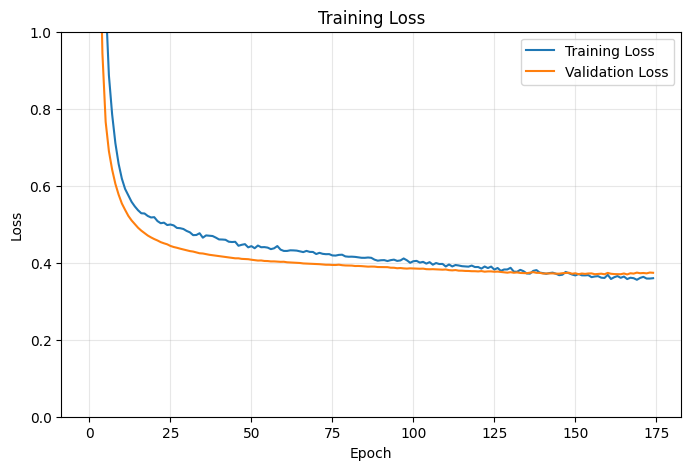

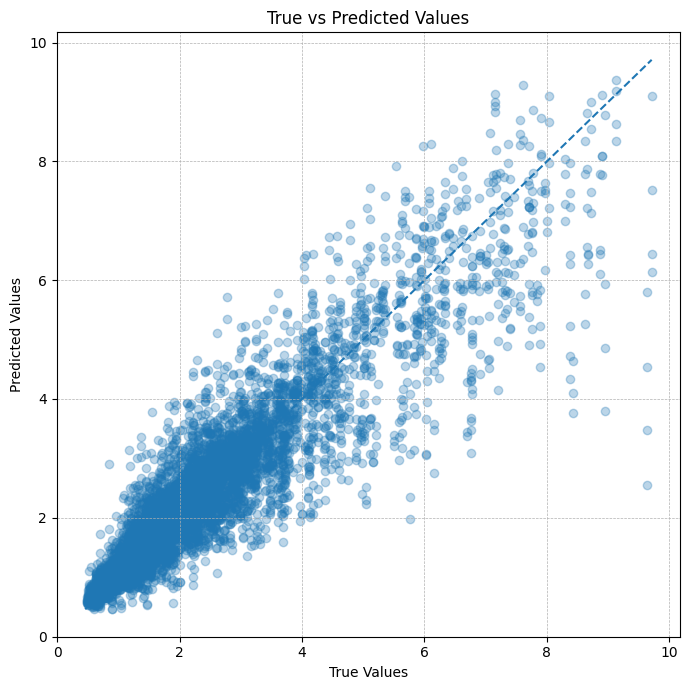

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

MultiFoundationCore test metrics
horizon      MSE      MAE     SMAPE     NNSE       R2
      1 0.117786 0.210802  8.906023 0.949133 0.946407
      2 0.297478 0.335338 13.738601 0.884824 0.869832
      3 0.469388 0.448917 18.582777 0.833611 0.800399
      4 0.610762 0.525877 21.988354 0.796158 0.743968
   mean 0.373853 0.380234 15.803939 0.865932 0.840152


In [ ]:


config = MFCConfig(
    prediction_dir="./Predictoins",
    test_length=200,
    look_back_size=10,
    output_horizon=4,
    expert_lstm_units=16,
    history_lstm_units=16,
    num_heads=8,
    key_dim=16,
    value_dim=16,
    ff_units=16,
    decoder_units=16,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    seed=100,
    use_early_stopping=False,
    use_reduce_lr=False,
)

results = run_pipeline(config)



Loaded PatchTSTh_predictions.pkl as expert 'PatchTSTh'.
Loaded iTransformerh_predictions.pkl as expert 'iTransformerh'.
Loaded TFT_predictions.pkl as expert 'TFT'.
Loaded PatchTSTt_predictions.pkl as expert 'PatchTSTt'.
Loaded iTransformer_predictions.pkl as expert 'iTransformer'.
Loaded PatchTSTc_predictions.pkl as expert 'PatchTSTc'.
Loaded VanillaTransformer_predictions.pkl as expert 'VanillaTransformer'.
Loaded PatchTST_predictions.pkl as expert 'PatchTST'.
Loaded TiDE_predictions.pkl as expert 'TiDE'.
Loaded PatchTSTm_predictions.pkl as expert 'PatchTSTm'.

Loaded prediction dataframe using notebook-compatible concatenation.
Loaded expert models: ['PatchTSTh', 'iTransformerh', 'TFT', 'PatchTSTt', 'iTransformer', 'PatchTSTc', 'VanillaTransformer', 'PatchTST', 'TiDE', 'PatchTSTm']
Expert models used by MFC: ['PatchTST', 'PatchTSTm', 'PatchTSTt', 'PatchTSTc', 'VanillaTransformer', 'iTransformer', 'iTransformerh', 'PatchTSTh', 'TFT', 'TiDE']
Number of expert prediction features: 40
Nu

Model: "MultiFoundationCore"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfc_input           │ (None, 10, 41)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ history_slice       │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_00_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_01_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_02_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_03_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_04_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_05_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_06_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_07_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_08_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_09_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_10_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_11_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_12_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_13_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_14_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0] 

 Total params: 56,708 (221.52 KB)

 Trainable params: 56,708 (221.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/175
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 7.4029Epoch 001 | train MSE: 6.756541 | val MSE: 6.147423
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - loss: 6.7565 - val_loss: 6.1474
Epoch 2/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 5.4833Epoch 002 | train MSE: 4.857282 | val MSE: 3.697640
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 4.8573 - val_loss: 3.6976
Epoch 3/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.5101Epoch 003 | train MSE: 3.108555 | val MSE: 2.292689
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 3.1086 - val_loss: 2.2927
Epoch 4/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.4250Epoch 004 | train MSE: 2.141763 | val MSE: 1.447489
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 2.1418 - val_loss: 1.4475
Epoch 5/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.6635Epoch 005 | train MSE: 1.469608 | val MSE: 0.968406
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.4696 - val_loss: 0.9684
Epoch 6/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 

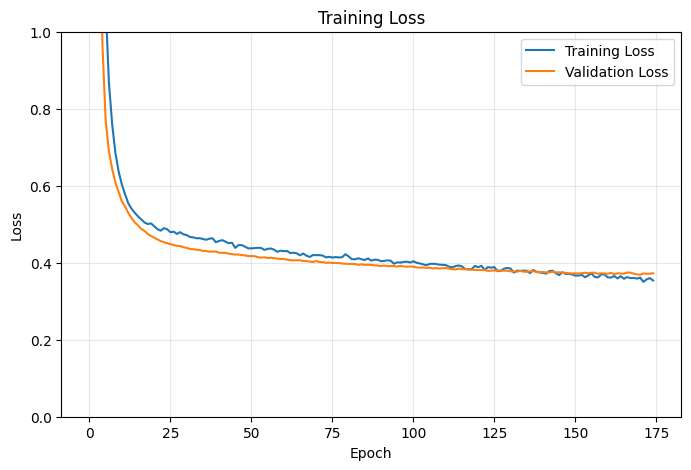

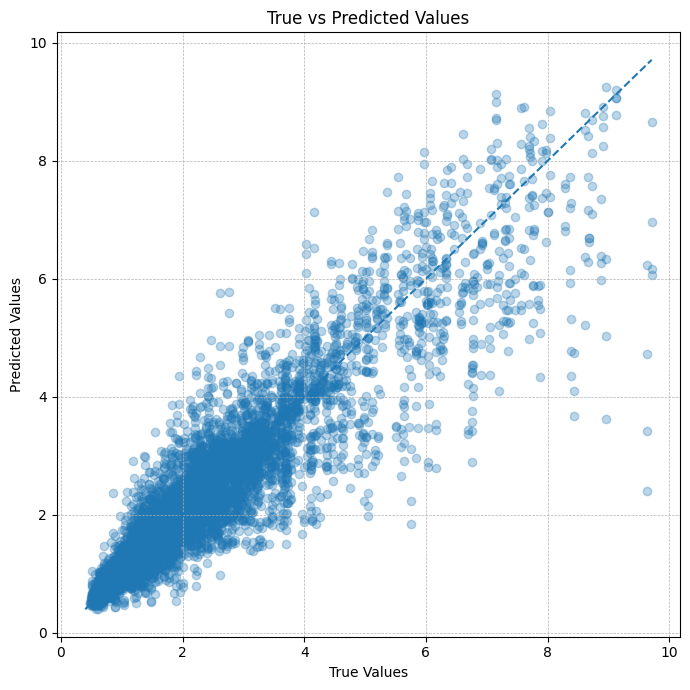

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

MultiFoundationCore test metrics
horizon      MSE      MAE     SMAPE     NNSE       R2
      1 0.111502 0.202214  8.362251 0.951716 0.949266
      2 0.299700 0.336961 13.909732 0.884064 0.868860
      3 0.462902 0.436105 18.389473 0.835531 0.803157
      4 0.616218 0.516533 21.971031 0.794711 0.741681
   mean 0.372580 0.372953 15.658122 0.866506 0.840741


In [ ]:


config = MFCConfig(
    prediction_dir="./Predictoins",
    test_length=200,
    look_back_size=10,
    output_horizon=4,
    expert_lstm_units=16,
    history_lstm_units=16,
    num_heads=8,
    key_dim=16,
    value_dim=16,
    ff_units=16,
    decoder_units=16,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    seed=500,
    use_early_stopping=False,
    use_reduce_lr=False,
)

results = run_pipeline(config)



Loaded PatchTSTh_predictions.pkl as expert 'PatchTSTh'.
Loaded iTransformerh_predictions.pkl as expert 'iTransformerh'.
Loaded TFT_predictions.pkl as expert 'TFT'.
Loaded PatchTSTt_predictions.pkl as expert 'PatchTSTt'.
Loaded iTransformer_predictions.pkl as expert 'iTransformer'.
Loaded PatchTSTc_predictions.pkl as expert 'PatchTSTc'.
Loaded VanillaTransformer_predictions.pkl as expert 'VanillaTransformer'.
Loaded PatchTST_predictions.pkl as expert 'PatchTST'.
Loaded TiDE_predictions.pkl as expert 'TiDE'.
Loaded PatchTSTm_predictions.pkl as expert 'PatchTSTm'.

Loaded prediction dataframe using notebook-compatible concatenation.
Loaded expert models: ['PatchTSTh', 'iTransformerh', 'TFT', 'PatchTSTt', 'iTransformer', 'PatchTSTc', 'VanillaTransformer', 'PatchTST', 'TiDE', 'PatchTSTm']
Expert models used by MFC: ['PatchTST', 'PatchTSTm', 'PatchTSTt', 'PatchTSTc', 'VanillaTransformer', 'iTransformer', 'iTransformerh', 'PatchTSTh', 'TFT', 'TiDE']
Number of expert prediction features: 40
Nu

Model: "MultiFoundationCore"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfc_input           │ (None, 10, 41)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ history_slice       │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_00_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_01_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_02_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_03_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_04_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_05_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_06_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_07_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_08_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_09_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_10_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_11_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_12_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_13_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_14_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0] 

 Total params: 56,708 (221.52 KB)

 Trainable params: 56,708 (221.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/175
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 6.9766Epoch 001 | train MSE: 6.683030 | val MSE: 6.621582
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - loss: 6.6830 - val_loss: 6.6216
Epoch 2/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 5.9907Epoch 002 | train MSE: 5.666973 | val MSE: 5.053023
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 5.6670 - val_loss: 5.0530
Epoch 3/175
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4.3721Epoch 003 | train MSE: 3.766674 | val MSE: 2.226700
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 3.7667 - val_loss: 2.2267
Epoch 4/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 2.3907Epoch 004 | train MSE: 2.139178 | val MSE: 1.313569
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 2.1392 - val_loss: 1.3136
Epoch 5/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.6579Epoch 005 | train MSE: 1.507243 | val MSE: 0.967784
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 1.5072 - val_loss: 0.9678
Epoch 6/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 

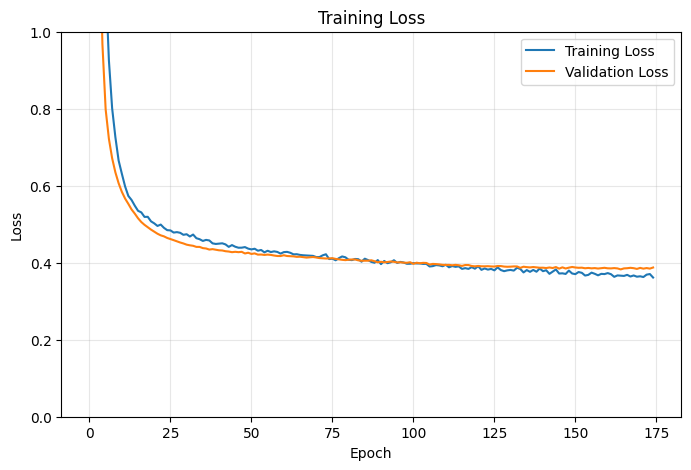

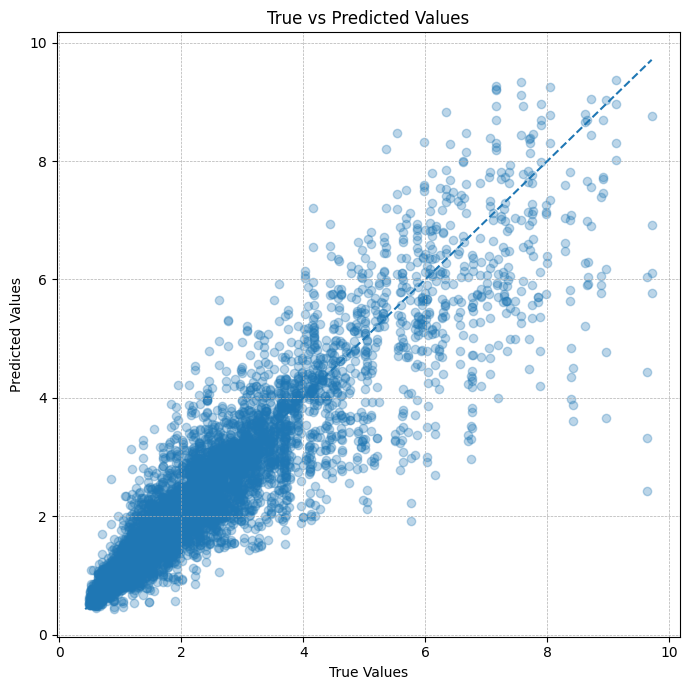

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

MultiFoundationCore test metrics
horizon      MSE      MAE     SMAPE     NNSE       R2
      1 0.116177 0.204481  8.360088 0.949793 0.947139
      2 0.312572 0.335399 13.577626 0.879683 0.863227
      3 0.487334 0.440740 18.081280 0.828341 0.792768
      4 0.634217 0.518200 21.540560 0.789974 0.734136
   mean 0.387575 0.374705 15.389889 0.861948 0.834317


In [ ]:


config = MFCConfig(
    prediction_dir="./Predictoins",
    test_length=200,
    look_back_size=10,
    output_horizon=4,
    expert_lstm_units=16,
    history_lstm_units=16,
    num_heads=8,
    key_dim=16,
    value_dim=16,
    ff_units=16,
    decoder_units=16,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    seed=3,
    use_early_stopping=False,
    use_reduce_lr=False,
)

results = run_pipeline(config)



Loaded PatchTSTh_predictions.pkl as expert 'PatchTSTh'.
Loaded iTransformerh_predictions.pkl as expert 'iTransformerh'.
Loaded TFT_predictions.pkl as expert 'TFT'.
Loaded PatchTSTt_predictions.pkl as expert 'PatchTSTt'.
Loaded iTransformer_predictions.pkl as expert 'iTransformer'.
Loaded PatchTSTc_predictions.pkl as expert 'PatchTSTc'.
Loaded VanillaTransformer_predictions.pkl as expert 'VanillaTransformer'.
Loaded PatchTST_predictions.pkl as expert 'PatchTST'.
Loaded TiDE_predictions.pkl as expert 'TiDE'.
Loaded PatchTSTm_predictions.pkl as expert 'PatchTSTm'.

Loaded prediction dataframe using notebook-compatible concatenation.
Loaded expert models: ['PatchTSTh', 'iTransformerh', 'TFT', 'PatchTSTt', 'iTransformer', 'PatchTSTc', 'VanillaTransformer', 'PatchTST', 'TiDE', 'PatchTSTm']
Expert models used by MFC: ['PatchTST', 'PatchTSTm', 'PatchTSTt', 'PatchTSTc', 'VanillaTransformer', 'iTransformer', 'iTransformerh', 'PatchTSTh', 'TFT', 'TiDE']
Number of expert prediction features: 40
Nu

Model: "MultiFoundationCore"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfc_input           │ (None, 10, 41)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ history_slice       │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_00_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_01_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_02_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_03_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_04_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_05_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_06_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_07_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_08_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_09_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_10_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_11_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_12_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_13_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_14_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0] 

 Total params: 56,708 (221.52 KB)

 Trainable params: 56,708 (221.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 7.3925Epoch 001 | train MSE: 6.829391 | val MSE: 6.113698
90/90 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - loss: 6.8294 - val_loss: 6.1137
Epoch 2/175
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 5.2860Epoch 002 | train MSE: 4.394007 | val MSE: 2.527947
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 4.3940 - val_loss: 2.5279
Epoch 3/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.7160Epoch 003 | train MSE: 2.395623 | val MSE: 1.542526
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 2.3956 - val_loss: 1.5425
Epoch 4/175
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.9329Epoch 004 | train MSE: 1.730444 | val MSE: 1.120133
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.7304 - val_loss: 1.1201
Epoch 5/175
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.4332Epoch 005 | train MSE: 1.269413 | val MSE: 0.861765
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.2694 - val_loss: 0.8618
Epoch 6/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 

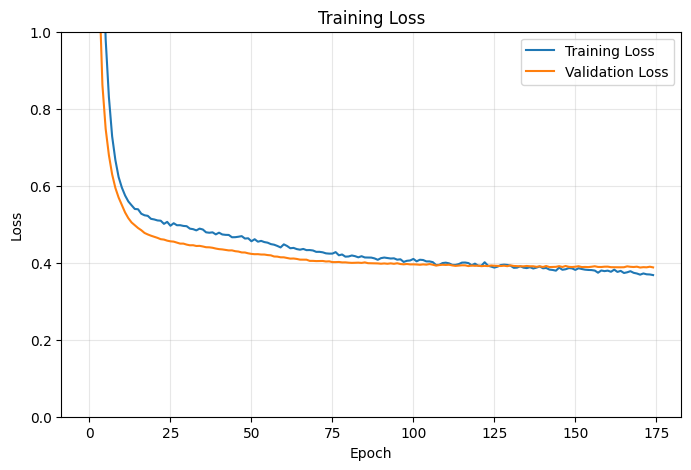

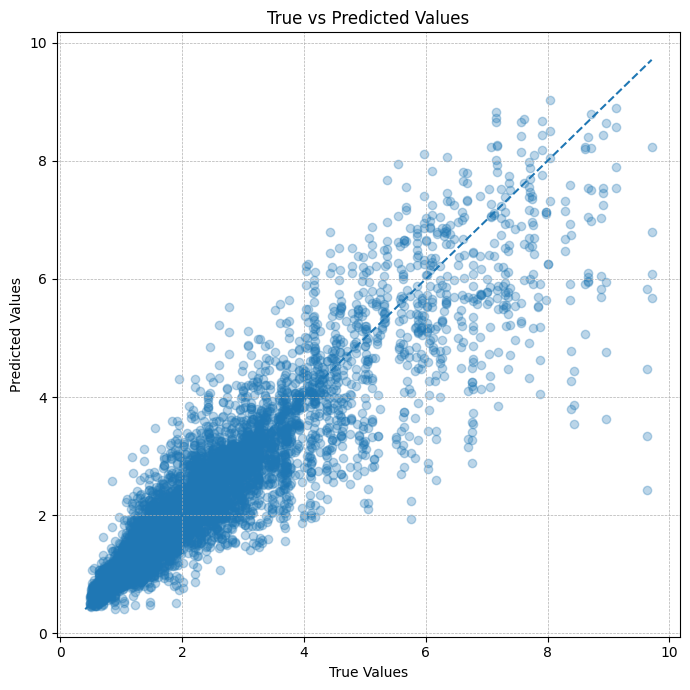

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

MultiFoundationCore test metrics
horizon      MSE      MAE     SMAPE     NNSE       R2
      1 0.126440 0.214902  8.823193 0.945599 0.942470
      2 0.313600 0.337840 13.788385 0.879335 0.862777
      3 0.476046 0.432677 17.929913 0.831648 0.797568
      4 0.635447 0.514802 21.523991 0.789653 0.733621
   mean 0.387883 0.375055 15.516370 0.861559 0.834109


In [ ]:


config = MFCConfig(
    prediction_dir="./Predictoins",
    test_length=200,
    look_back_size=10,
    output_horizon=4,
    expert_lstm_units=16,
    history_lstm_units=16,
    num_heads=8,
    key_dim=16,
    value_dim=16,
    ff_units=16,
    decoder_units=16,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    seed=2,
    use_early_stopping=False,
    use_reduce_lr=False,
)

results = run_pipeline(config)



Loaded PatchTSTh_predictions.pkl as expert 'PatchTSTh'.
Loaded iTransformerh_predictions.pkl as expert 'iTransformerh'.
Loaded TFT_predictions.pkl as expert 'TFT'.
Loaded PatchTSTt_predictions.pkl as expert 'PatchTSTt'.
Loaded iTransformer_predictions.pkl as expert 'iTransformer'.
Loaded PatchTSTc_predictions.pkl as expert 'PatchTSTc'.
Loaded VanillaTransformer_predictions.pkl as expert 'VanillaTransformer'.
Loaded PatchTST_predictions.pkl as expert 'PatchTST'.
Loaded TiDE_predictions.pkl as expert 'TiDE'.
Loaded PatchTSTm_predictions.pkl as expert 'PatchTSTm'.

Loaded prediction dataframe using notebook-compatible concatenation.
Loaded expert models: ['PatchTSTh', 'iTransformerh', 'TFT', 'PatchTSTt', 'iTransformer', 'PatchTSTc', 'VanillaTransformer', 'PatchTST', 'TiDE', 'PatchTSTm']
Expert models used by MFC: ['PatchTST', 'PatchTSTm', 'PatchTSTt', 'PatchTSTc', 'VanillaTransformer', 'iTransformer', 'iTransformerh', 'PatchTSTh', 'TFT', 'TiDE']
Number of expert prediction features: 40
Nu

Model: "MultiFoundationCore"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfc_input           │ (None, 10, 41)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ history_slice       │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_00_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_01_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_02_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_03_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_04_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_05_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_06_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_07_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_08_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_09_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_10_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_11_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_12_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_13_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_14_slice     │ (None, 10, 1)     │          0 │ mfc_input[0][0] 

 Total params: 56,708 (221.52 KB)

 Trainable params: 56,708 (221.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/175
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 7.0653Epoch 001 | train MSE: 7.099461 | val MSE: 7.378646
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - loss: 7.0995 - val_loss: 7.3786
Epoch 2/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 6.4218Epoch 002 | train MSE: 6.308784 | val MSE: 5.873973
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 6.3088 - val_loss: 5.8740
Epoch 3/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 4.8610Epoch 003 | train MSE: 4.415975 | val MSE: 3.121001
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 4.4160 - val_loss: 3.1210
Epoch 4/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.9183Epoch 004 | train MSE: 2.795662 | val MSE: 2.081064
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 2.7957 - val_loss: 2.0811
Epoch 5/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 2.1453Epoch 005 | train MSE: 2.072913 | val MSE: 1.428086
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 2.0729 - val_loss: 1.4281
Epoch 6/175
89/90 ━━━━━━━━━━━━━━━━━━━━ 

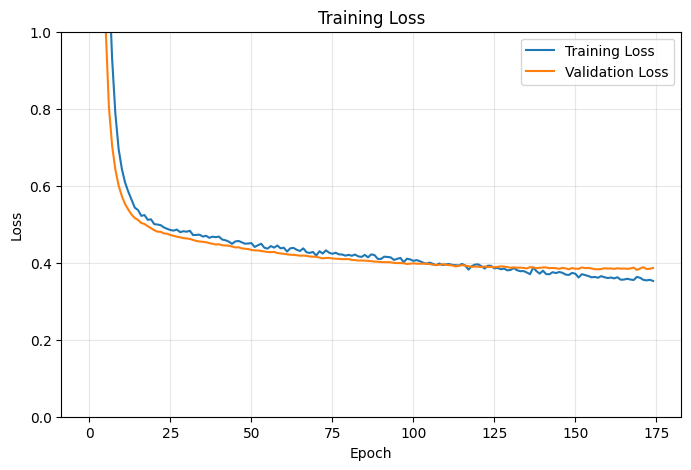

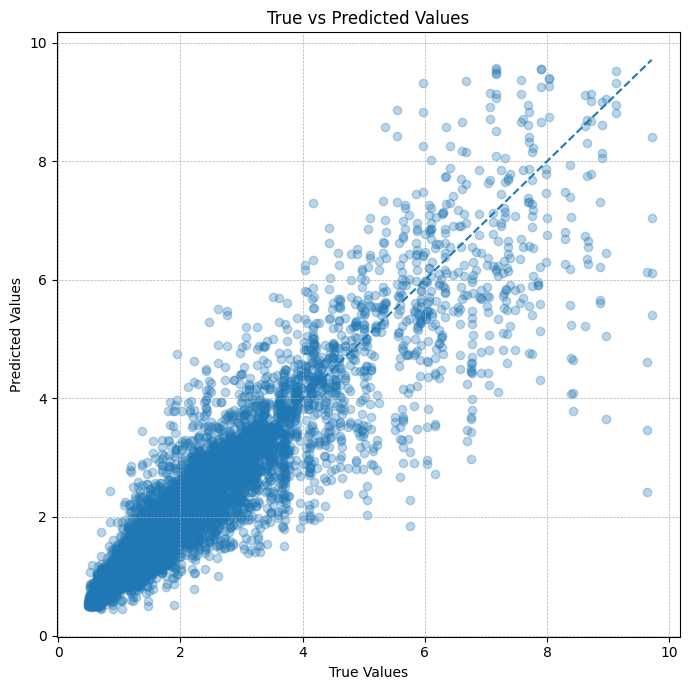

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

MultiFoundationCore test metrics
horizon      MSE      MAE     SMAPE     NNSE       R2
      1 0.118107 0.210426  8.812298 0.949002 0.946261
      2 0.309126 0.338628 13.774443 0.880852 0.864735
      3 0.478607 0.436940 17.911669 0.830895 0.796479
      4 0.639567 0.514556 21.595648 0.788577 0.731893
   mean 0.386352 0.375137 15.523514 0.862331 0.834842


In [ ]:


config = MFCConfig(
    prediction_dir="./Predictoins",
    test_length=200,
    look_back_size=10,
    output_horizon=4,
    expert_lstm_units=16,
    history_lstm_units=16,
    num_heads=8,
    key_dim=16,
    value_dim=16,
    ff_units=16,
    decoder_units=16,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    seed=1,
    use_early_stopping=False,
    use_reduce_lr=False,
)

results = run_pipeline(config)



In [57]:
# Optional: compare one individual expert against MFC on the same aligned test origins.
# All experts:
all_experts = [
        "PatchTST",
        "PatchTSTm",
        "PatchTSTt",
        "PatchTSTc",
        "VanillaTransformer",
        "iTransformer",
        "iTransformerh",
        "PatchTSTh",
        "TFT",
        "TiDE",
        ]


for i in all_experts:
    baseline_metrics = evaluate_expert_baseline_aligned(
        df=results["df"],
        y_df=results["y_df"],
        model_name=i,
        config=config,
        check_date_alignment=False,
        )



Baseline expert metrics: PatchTST
horizon n_valid_per_series      MSE      MAE     SMAPE     NNSE       R2
      1                200 0.129103 0.208096  8.170697 0.948652 0.945873
      2                199 0.355794 0.342658 13.491179 0.870179 0.850811
      3                198 0.527070 0.439640 17.916452 0.819003 0.779003
      4                197 0.709147 0.526038 22.256959 0.770847 0.702725
   mean                    0.430278 0.379108 15.458822 0.852170 0.819603

Baseline expert metrics: PatchTSTm
horizon n_valid_per_series      MSE      MAE     SMAPE     NNSE       R2
      1                200 0.132069 0.212485  8.442348 0.947534 0.944629
      2                199 0.343036 0.344468 13.640258 0.874248 0.856160
      3                198 0.519832 0.436546 17.753066 0.821043 0.782037
      4                197 0.666873 0.510258 21.064936 0.781523 0.720447
   mean                    0.415453 0.375939 15.225152 0.856087 0.825818

Baseline expert metrics: PatchTSTt
horizon n_valid_p

# Baseline Expert Metrics

This section reports the aligned baseline performance of each expert model across forecast horizons 1–4.  
Lower values are better for **MSE**, **MAE**, and **SMAPE**. Higher values are better for **NNSE** and **R²**.

---

## Summary: Mean Performance Across Horizons

| Rank | Model | Mean MSE ↓ | Mean MAE ↓ | Mean SMAPE ↓ | Mean NNSE ↑ | Mean R² ↑ |
|---:|---|---:|---:|---:|---:|---:|
| 1 | **PatchTST-hospitalization** | **0.397300** | **0.366674** | **14.950654** | **0.861430** | **0.833429** |
| 2 | PatchTST-covid19 | 0.411609 | 0.377008 | 15.426183 | 0.857090 | 0.827430 |
| 3 | PatchTST-m4 | 0.415453 | 0.375939 | 15.225152 | 0.856087 | 0.825818 |
| 4 | PatchTST | 0.430278 | 0.379108 | 15.458822 | 0.852170 | 0.819603 |
| 5 | PatchTST-trafficl | 0.430833 | 0.379843 | 15.282883 | 0.851639 | 0.819370 |
| 6 | TFT | 0.455457 | 0.415411 | 16.958321 | 0.844492 | 0.809047 |
| 7 | iTransformer | 0.472801 | 0.421137 | 19.129754 | 0.839666 | 0.801775 |
| 8 | iTransformer-hospitalization | 0.474577 | 0.419412 | 18.376175 | 0.838793 | 0.801030 |
| 9 | VanillaTransformer | 0.507529 | 0.433740 | 17.110732 | 0.829919 | 0.787215 |
| 10 | TiDE | 0.588605 | 0.426515 | 16.772222 | 0.810954 | 0.753224 |

---

## Key Observation

Among all evaluated baseline experts, **PatchTSTh** achieves the best overall mean performance, with the lowest mean **MSE**, **MAE**, and **SMAPE**, and the highest mean **NNSE** and **R²**. The PatchTST-family variants consistently outperform the other baseline experts across most aggregate metrics.

---

# Detailed Results by Expert

## PatchTST

| Horizon | Valid Samples / Series | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 200 | 0.129103 | 0.208096 | 8.170697 | 0.948652 | 0.945873 |
| 2 | 199 | 0.355794 | 0.342658 | 13.491179 | 0.870179 | 0.850811 |
| 3 | 198 | 0.527070 | 0.439640 | 17.916452 | 0.819003 | 0.779003 |
| 4 | 197 | 0.709147 | 0.526038 | 22.256959 | 0.770847 | 0.702725 |
| **Mean** | — | **0.430278** | **0.379108** | **15.458822** | **0.852170** | **0.819603** |

---

## PatchTSTm

| Horizon | Valid Samples / Series | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 200 | 0.132069 | 0.212485 | 8.442348 | 0.947534 | 0.944629 |
| 2 | 199 | 0.343036 | 0.344468 | 13.640258 | 0.874248 | 0.856160 |
| 3 | 198 | 0.519832 | 0.436546 | 17.753066 | 0.821043 | 0.782037 |
| 4 | 197 | 0.666873 | 0.510258 | 21.064936 | 0.781523 | 0.720447 |
| **Mean** | — | **0.415453** | **0.375939** | **15.225152** | **0.856087** | **0.825818** |

---

## PatchTSTt

| Horizon | Valid Samples / Series | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 200 | 0.135538 | 0.214381 | 8.466250 | 0.946230 | 0.943175 |
| 2 | 199 | 0.359492 | 0.348632 | 13.716275 | 0.869006 | 0.849260 |
| 3 | 198 | 0.545433 | 0.442283 | 17.770244 | 0.813870 | 0.771303 |
| 4 | 197 | 0.682869 | 0.514076 | 21.178765 | 0.777448 | 0.713741 |
| **Mean** | — | **0.430833** | **0.379843** | **15.282883** | **0.851639** | **0.819370** |

---

## PatchTSTc

| Horizon | Valid Samples / Series | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 200 | 0.131959 | 0.214677 | 8.623400 | 0.947575 | 0.944675 |
| 2 | 199 | 0.345553 | 0.346154 | 13.894150 | 0.873442 | 0.855104 |
| 3 | 198 | 0.511927 | 0.439465 | 17.996671 | 0.823284 | 0.785352 |
| 4 | 197 | 0.656996 | 0.507735 | 21.190512 | 0.784060 | 0.724587 |
| **Mean** | — | **0.411609** | **0.377008** | **15.426183** | **0.857090** | **0.827430** |

---

## VanillaTransformer

| Horizon | Valid Samples / Series | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 200 | 0.187520 | 0.278455 | 11.540776 | 0.927111 | 0.921381 |
| 2 | 199 | 0.429900 | 0.406283 | 15.730360 | 0.847268 | 0.819737 |
| 3 | 198 | 0.588552 | 0.476305 | 18.737510 | 0.802068 | 0.753223 |
| 4 | 197 | 0.824142 | 0.573918 | 22.434281 | 0.743229 | 0.654519 |
| **Mean** | — | **0.507529** | **0.433740** | **17.110732** | **0.829919** | **0.787215** |

---

## iTransformer

| Horizon | Valid Samples / Series | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 200 | 0.169232 | 0.248204 | 10.305082 | 0.933749 | 0.929048 |
| 2 | 199 | 0.383274 | 0.382707 | 16.787400 | 0.861540 | 0.839288 |
| 3 | 198 | 0.570664 | 0.483107 | 22.465447 | 0.806923 | 0.760724 |
| 4 | 197 | 0.768033 | 0.570531 | 26.961086 | 0.756453 | 0.678040 |
| **Mean** | — | **0.472801** | **0.421137** | **19.129754** | **0.839666** | **0.801775** |

---

## iTransformerh

| Horizon | Valid Samples / Series | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 200 | 0.178592 | 0.260304 | 10.802390 | 0.930340 | 0.925124 |
| 2 | 199 | 0.390500 | 0.382256 | 16.282858 | 0.859297 | 0.836258 |
| 3 | 198 | 0.574528 | 0.477644 | 21.414693 | 0.805869 | 0.759104 |
| 4 | 197 | 0.754688 | 0.557442 | 25.004758 | 0.759667 | 0.683634 |
| **Mean** | — | **0.474577** | **0.419412** | **18.376175** | **0.838793** | **0.801030** |

---

## PatchTSTh

| Horizon | Valid Samples / Series | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 200 | 0.123667 | 0.206784 | 8.173498 | 0.950708 | 0.948152 |
| 2 | 199 | 0.325687 | 0.335427 | 13.335754 | 0.879844 | 0.863435 |
| 3 | 198 | 0.500877 | 0.427939 | 17.478331 | 0.826436 | 0.789985 |
| 4 | 197 | 0.638970 | 0.496546 | 20.815034 | 0.788733 | 0.732144 |
| **Mean** | — | **0.397300** | **0.366674** | **14.950654** | **0.861430** | **0.833429** |

---

## TFT

| Horizon | Valid Samples / Series | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 200 | 0.170157 | 0.247880 | 9.861139 | 0.933411 | 0.928660 |
| 2 | 199 | 0.353219 | 0.370751 | 14.929585 | 0.870997 | 0.851890 |
| 3 | 198 | 0.556823 | 0.478175 | 19.553683 | 0.810719 | 0.766527 |
| 4 | 197 | 0.741629 | 0.564837 | 23.488877 | 0.762840 | 0.689109 |
| **Mean** | — | **0.455457** | **0.415411** | **16.958321** | **0.844492** | **0.809047** |

---

## TiDE

| Horizon | Valid Samples / Series | MSE ↓ | MAE ↓ | SMAPE ↓ | NNSE ↑ | R² ↑ |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 200 | 0.170745 | 0.234200 | 9.299245 | 0.933196 | 0.928414 |
| 2 | 199 | 0.449836 | 0.382460 | 14.962495 | 0.841310 | 0.811377 |
| 3 | 198 | 0.734293 | 0.497614 | 19.516225 | 0.764593 | 0.692115 |
| 4 | 197 | 0.999546 | 0.591784 | 23.310921 | 0.704717 | 0.580990 |
| **Mean** | — | **0.588605** | **0.426515** | **16.772222** | **0.810954** | **0.753224** |